# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [67]:
R = 2.
H = 1.

NGSOLVE = True

lc = 1.

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [68]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

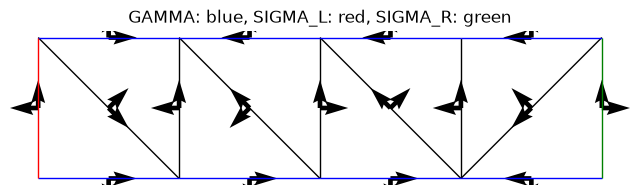

In [69]:
waveguide.plot()

In [70]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [71]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [72]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.LEFT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [73]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [74]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [75]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, NtD_modes=NtD_modes, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [76]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 9
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

72

and an assembler:

In [77]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [78]:
from trefftz.problem import Problem
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [79]:
A = P.assemble_LHS()

Interior: 100%|██████████| 7/7 [00:00<00:00, 38.22edge/s]


assembling local operators
region: Gamma


100%|██████████| 8/8 [00:00<00:00, 387.45edge/s]


region: Sigma_L


100%|██████████| 1/1 [00:00<00:00, 325.44edge/s]


region: Sigma_R


100%|██████████| 1/1 [00:00<00:00, 331.09edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 1/1 [00:00<00:00,  4.85edge/s]


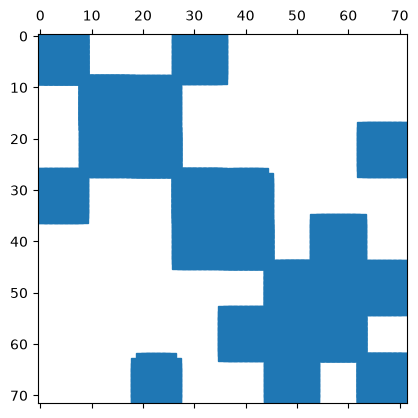

In [80]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [81]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [82]:
b = P.assemble_RHS()

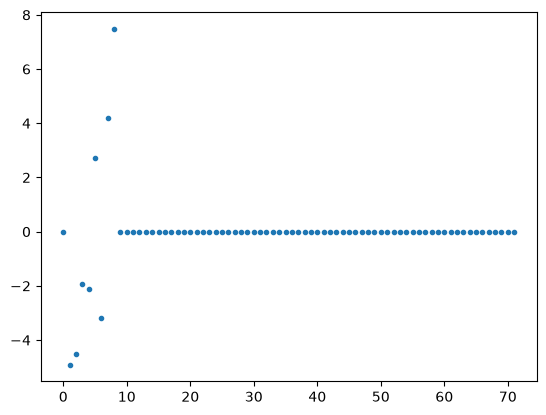

In [83]:
plt.plot(b.real,'.')

In [84]:
import numpy as np
np.count_nonzero(b)/N_theta

np.float64(1.0)

In [85]:
P.solve()

In [86]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 0.11845412-7.76230484e-02j, -0.43549604+2.13170857e-02j,
         0.18179692+1.33469574e-01j, -0.13404411+7.56710095e-02j,
         0.06949363+4.23064051e-02j,  0.04581476+3.79297674e-02j,
        -0.00621697-1.07944599e-02j, -0.04433855+1.77708214e-01j,
        -0.20481741+3.47993363e-01j],
       [ 0.06977302+6.27472265e-02j, -0.00413969-7.59710948e-02j,
         0.02765185-1.42474380e-02j,  0.00804959+7.86651410e-03j,
         0.00053799-1.99284696e-03j,  0.00076179+9.28616972e-05j,
         0.00902693+1.08742637e-03j,  0.03463123-9.30530335e-03j,
        -0.03820337-9.19800337e-02j],
       [ 0.0414782 +5.91226600e-02j,  0.06977137-4.02995880e-02j,
        -0.01313174-2.05550512e-02j,  0.0027541 +1.45857150e-02j,
        -0.00279182+5.54103905e-03j, -0.00801372+1.74165153e-02j,
        -0.03827049+2.77840120e-03j,  0.04002644-2.01272055e-02j,
        -0.03265721-9.56851338e-02j],
       [-0.0201571 -8.11389514e-02j, -0.4341973 +4.86342817e-02j,
         0.12232664+9.920531

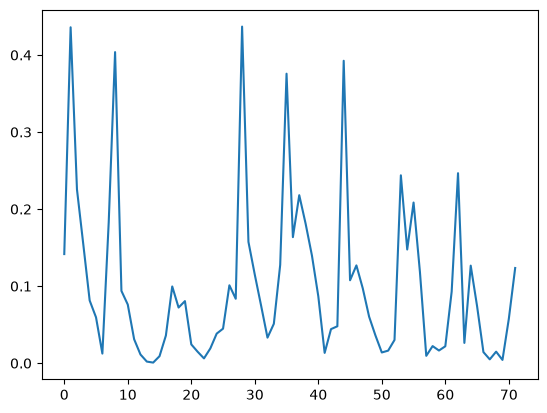

In [87]:
plt.plot(np.abs(P.u_h.coefficients))

In [88]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

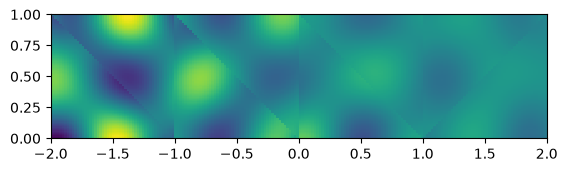

In [89]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

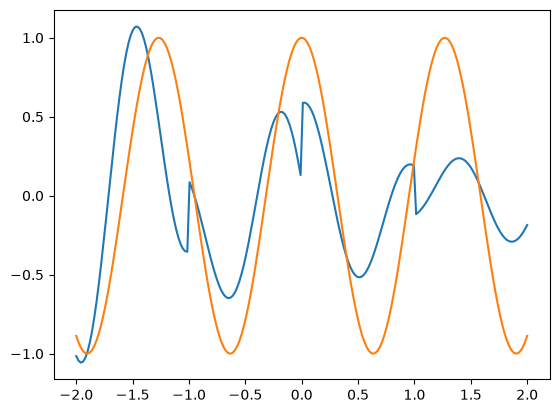

In [90]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)

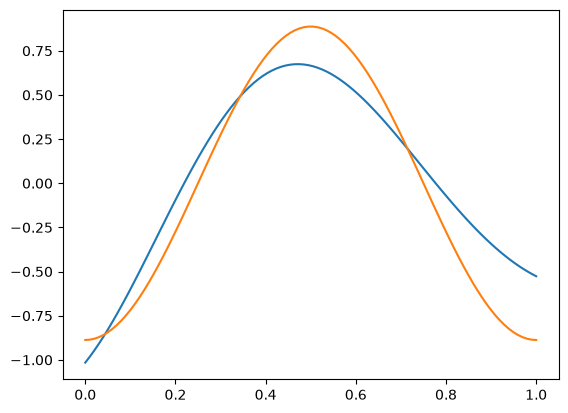

In [91]:
plt.plot(y,Z[:,0].real)
plt.plot(y,np.exp(-1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*R).real*np.cos(t*np.pi/H*y))